,Unique id,channel_name,category,Sub-category,Customer Remarks,Order_id,order_date_time,Issue_reported at,issue_responded,Survey_response_Date,Customer_City,Product_category,Item_price,connected_handling_time,Agent_name,Supervisor,Manager,Tenure Bucket,Agent Shift,CSAT Score
0,7e9ae164-6a8b-4521-a2d4-58f7c9fff13f,Outcall,Product Queries,Life Insurance,NaN,c27c9bb4-fa36-4140-9f1f-21009254ffdb,NaN,01/08/2023 11:13,01/08/2023 11:47,01-Aug-23,NaN,NaN,NaN,NaN,Richard Buchanan,Mason Gupta,Jennifer Nguyen,On Job Training,Morning,5
1,b07ec1b0-f376-43b6-86df-ec03da3b2e16,Outcall,Product Queries,Product Specific Information,NaN,d406b0c7-ce17-4654-b9de-f08d421254bd,NaN,01/08/2023 12:52,01/08/2023 12:54,01-Aug-23,NaN,NaN,NaN,NaN,Vicki Collins,Dylan Kim,Michael Lee,>90,Morning,5
2,200814dd-27c7-4149-ba2b-bd3af3092880,Inbound,Order Related,Installation/demo,NaN,c273368d-b961-44cb-beaf-62d6fd6c00d5,NaN,01/08/2023 20:16,01/08/2023 20:38,01-Aug-23,NaN,NaN,NaN,NaN,Duane Norman,Jackson Park,William Kim,On Job Training,Evening,5
3,eb0d3e53-c1ca-42d3-8486-e42c8d622135,Inbound,Returns,Reverse Pickup Enquiry,NaN,5aed0059-55a4-4ec6-bb54-97942092020a,NaN,01/08/2023 20:56,01/08/2023 21:16,01-Aug-23,NaN,NaN,NaN,NaN,Patrick Flores,Olivia Wang,John Smith,>90,Evening,5
4,ba903143-1e54-406c-b969-46c52f92e5df,Inbound,Cancellation,Not Needed,NaN,e8bed5a9-6933-4aff-9dc6-ccefd7dcde59,NaN,01/08/2023 10:30,01/08/2023 10:32,01-Aug-23,NaN,NaN,NaN,NaN,Christopher Sanchez,Austin Johnson,Michael Lee,0-30,Morning,5
5,1cfde5b9-6112-44fc-8f3b-892196137a62,Email,Returns,Fraudulent User,NaN,a2938961-2833-45f1-83d6-678d9555c603,NaN,01/08/2023 15:13,01/08/2023 18:39,01-Aug-23,NaN,NaN,NaN,NaN,Desiree Newton,Emma Park,John Smith,0-30,Morning,5
6,11a3ffd8-1d6b-4806-b198-c60b5934c9bc,Outcall,Product Queries,Product Specific Information,NaN,bfcb562b-9a2f-4cca-aa79-fd4e2952f901,NaN,01/08/2023 15:31,01/08/2023 23:52,01-Aug-23,NaN,NaN,NaN,NaN,Shannon Hicks,Aiden Patel,Olivia Tan,>90,Morning,5
7,372b51a5-fa19-4a31-a4b8-a21de117d75e,Inbound,Returns,Exchange / Replacement,Very good,88537e0b-5ffa-43f9-bbe2-fe57a0f4e4ae,NaN,01/08/2023 16:17,01/08/2023 16:23,01-Aug-23,NaN,NaN,NaN,NaN,Laura Smith,Evelyn Kimura,Jennifer Nguyen,On Job Training,Evening,5
8,6e4413db-4e16-42fc-ac92-2f402e3df03c,Inbound,Returns,Missing,Shopzilla app and it's all coustomer care serv...,e6be9713-13c3-493c-8a91-2137cbbfa7e6,NaN,01/08/2023 21:03,01/08/2023 21:07,01-Aug-23,NaN,NaN,NaN,NaN,David Smith,Nathan Patel,John Smith,>90,Split,5
9,b0a65350-64a5-4603-8b9a-a24a4a145d08,Inbound,Shopzilla Related,General Enquiry,NaN,c7caa804-2525-499e-b202-4c781cb68974,NaN,01/08/2023 23:31,01/08/2023 23:36,01-Aug-23,NaN,NaN,NaN,NaN,Tabitha Ayala,Amelia Tanaka,Michael Lee,31-60,Evening,5


,precision,recall,f1-score,support
0,0.41,0.01,0.02,2971.00
1,0.83,1.00,0.90,14211.00
accuracy,0.83,0.83,0.83,0.83
macro avg,0.62,0.50,0.46,17182.00
weighted avg,0.76,0.83,0.75,17182.00


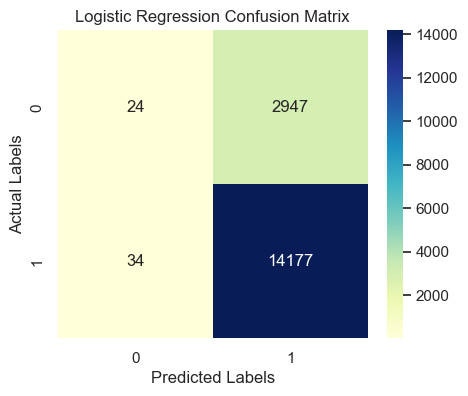

,precision,recall,f1-score,support
0,0.30,0.03,0.05,2971.00
1,0.83,0.99,0.90,14211.00
accuracy,0.82,0.82,0.82,0.82
macro avg,0.56,0.51,0.47,17182.00
weighted avg,0.74,0.82,0.75,17182.00


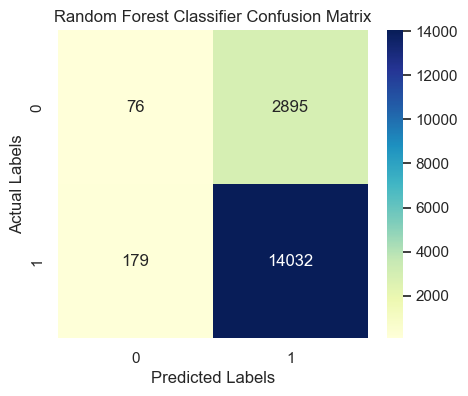

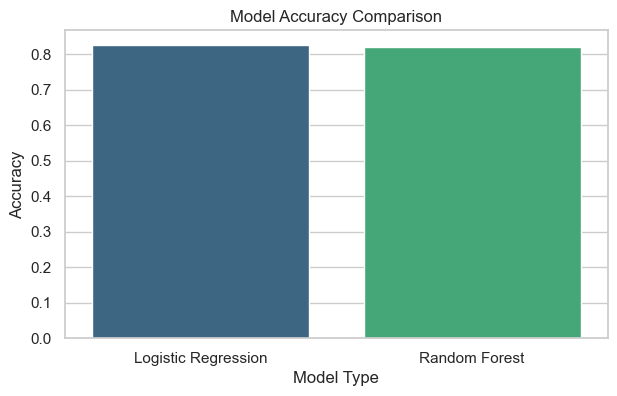

In [2]:
# ============================================================
# 📘 Week 6 Assignment: Supervised Learning (Classification)
# Project: E-commerce Recommendation System
# Milestone: Build a classification model to predict CSAT Category
# ============================================================

# 1️⃣ Import Required Libraries
from IPython.display import display, HTML
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid")

# ============================================================
# 2️⃣ Load Dataset
# ============================================================
df = pd.read_csv("Customer_support_data.csv")

display(HTML("<h2>📄 Dataset Preview (First 10 Rows)</h2>"))
display(df.head(10))

# ============================================================
# 3️⃣ Data Preprocessing
# ============================================================
# Explanation:
# - Drop unnecessary ID columns that are non-numeric and non-predictive.
# - Fill missing numeric values with their median.
# - Encode low-cardinality categorical columns using one-hot encoding.
# - Create a binary target column: CSAT_Category (1 for satisfied customers, 0 otherwise).

df = df.drop(columns=['Customer_ID', 'Order_ID', 'Product_ID'], errors='ignore')

# Fill numeric missing values
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Encode categorical columns with < 20 unique values
categorical_cols = df.select_dtypes(include='object').columns
low_cardinality_cols = [col for col in categorical_cols if df[col].nunique() < 20]
df = pd.get_dummies(df, columns=low_cardinality_cols, drop_first=True)

# Create binary target variable (CSAT_Category)
df['CSAT_Category'] = df['CSAT Score'].apply(lambda x: 1 if x >= 4 else 0)

# Separate features and target
X = df.drop(columns=['CSAT Score', 'CSAT_Category'])
y = df['CSAT_Category']

# Keep only numeric columns
X = X.select_dtypes(include=np.number)

# Display preprocessing summary
display(HTML(f"""
<div style='max-width:1100px;margin:0 auto;'>
<h3>✅ Preprocessing Summary</h3>
<ul>
<li><b>Shape after preprocessing:</b> {df.shape} → (Rows = Customer Records, Columns = Features + Target)</li>
<li><b>Features Shape:</b> {X.shape} → Predictor variables for classification</li>
<li><b>Target Shape:</b> {y.shape} → Binary target (CSAT Category)</li>
</ul>
</div>
"""))

# ============================================================
# 4️⃣ Train-Test Split
# ============================================================
# Explanation:
# - 80% data used for training (to learn patterns)
# - 20% data used for testing (to evaluate generalization)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

display(HTML(f"""
<div style='max-width:1100px;margin:0 auto;'>
<h3>✅ Train/Test Split Completed</h3>
<ul>
<li>Training Samples: {X_train.shape[0]} → Used for learning model parameters</li>
<li>Testing Samples: {X_test.shape[0]} → Used for evaluating model predictions</li>
</ul>
</div>
"""))

# ============================================================
# 5️⃣ Feature Standardization
# ============================================================
# Standardization Formula: 
#   z = (x - mean) / standard deviation
# This helps Logistic Regression converge faster and improves numerical stability.

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ============================================================
# 6️⃣ Logistic Regression Model
# ============================================================
# Logistic Regression Equation:
#   P(Y=1|X) = 1 / (1 + e^-(β0 + β1x1 + β2x2 + ... + βnxn))
# - It predicts probability of "satisfied" (1)
# - If P >= 0.5 → 1, else 0

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)

# ============================================================
# 7️⃣ Random Forest Classifier
# ============================================================
# Random Forest builds multiple Decision Trees and takes a majority vote.

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# ============================================================
# 8️⃣ Model Evaluation Function
# ============================================================
def evaluate_model_html(y_true, y_pred, model_name="Model"):
    acc = accuracy_score(y_true, y_pred)
    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    # ---- HTML Section ----
    display(HTML(f"<div style='max-width:1100px;margin:0 auto;'><h3>📊 {model_name} Evaluation Results</h3></div>"))
    display(HTML(f"<p><b>Accuracy:</b> {acc:.4f}</p>"))

    # Classification report
    df_report = pd.DataFrame(report).transpose().round(2)
    display(HTML(df_report.to_html(classes='table table-striped', border=0)))

    # ---- Confusion Matrix ----
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')
    plt.title(f"{model_name} Confusion Matrix")
    plt.xlabel("Predicted Labels")
    plt.ylabel("Actual Labels")
    plt.show()

    # ---- Interpretation ----
    tn, fp, fn, tp = cm.ravel()
    display(HTML(f"""
    <div style='max-width:1100px;margin:0 auto;'>
    <h4>🧩 Confusion Matrix Interpretation:</h4>
    <ul>
    <li><b>True Positives (TP):</b> {tp} → Correctly predicted satisfied customers</li>
    <li><b>True Negatives (TN):</b> {tn} → Correctly predicted unsatisfied customers</li>
    <li><b>False Positives (FP):</b> {fp} → Predicted satisfied but actually unsatisfied</li>
    <li><b>False Negatives (FN):</b> {fn} → Predicted unsatisfied but actually satisfied</li>
    </ul>
    </div>
    """))

# Evaluate both models
evaluate_model_html(y_test, y_pred_log, "Logistic Regression")
evaluate_model_html(y_test, y_pred_rf, "Random Forest Classifier")

# ============================================================
# 9️⃣ Manual Metric Calculations for Logistic Regression
# ============================================================
cm = confusion_matrix(y_test, y_pred_log)
tn, fp, fn, tp = cm.ravel()

# Formulas:
accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp) if (tp + fp) != 0 else 0
recall = tp / (tp + fn) if (tp + fn) != 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) != 0 else 0

display(HTML(f"""
<div style='max-width:1100px;margin:0 auto;'>
<h3>🧮 Manual Metric Calculations (Logistic Regression)</h3>
<p>Formulas:</p>
<ul>
<li><b>Accuracy</b> = (TP + TN) / (TP + TN + FP + FN)</li>
<li><b>Precision</b> = TP / (TP + FP)</li>
<li><b>Recall</b> = TP / (TP + FN)</li>
<li><b>F1 Score</b> = 2 × (Precision × Recall) / (Precision + Recall)</li>
</ul>

<p>📈 Substituting values:</p>
<ul>
<li>Accuracy = ({tp}+{tn})/({tp}+{tn}+{fp}+{fn}) = {accuracy:.4f}</li>
<li>Precision = {tp}/({tp}+{fp}) = {precision:.4f}</li>
<li>Recall = {tp}/({tp}+{fn}) = {recall:.4f}</li>
<li>F1 Score = 2×({precision:.4f}×{recall:.4f})/({precision:.4f}+{recall:.4f}) = {f1_score:.4f}</li>
</ul>
</div>
"""))

# ============================================================
# 🔟 Visualization: Model Comparison Chart (Fixed)
# ============================================================
scores = {
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ]
}
score_df = pd.DataFrame(scores)

plt.figure(figsize=(7,4))
sns.barplot(x='Model', y='Accuracy', hue='Model', data=score_df, palette='viridis', legend=False)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model Type")
plt.show()

display(HTML("""
<div style='max-width:1100px;margin:0 auto;'>
<h4>📊 Interpretation of Chart:</h4>
<p>This bar chart compares the accuracy of both classification models:</p>
<ul>
<li><b>Logistic Regression</b> provides a baseline linear model performance.</li>
<li><b>Random Forest</b> usually performs better because it captures non-linear relationships and feature interactions.</li>
<li>If both have similar accuracy, it indicates linear separability in data.</li>
</ul>
</div>
"""))

